# Train, Evaluate, and Track Baseline vs Challenger Models

In [0]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow
import mlflow.spark
from mlflow.models.signature import infer_signature

import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql.types import StringType

from sklearn.metrics import classification_report, confusion_matrix

## Environment & Volume Setup

In [0]:
# Environment & Volume Setup

# Build Unity Catalog Volume for MLflow (temporary)
spark.sql("CREATE VOLUME IF NOT EXISTS workspace.insurance_claim.mlflow_tmp")
tmp_vol_path = "/Volumes/workspace/insurance_claim/mlflow_tmp"

# Set the environment variable for Spark ML caching
os.environ["SPARKML_TEMP_DFS_PATH"] = tmp_vol_path

## ML Data Preparation (Encoding & Vector Assembly)

Goal: Convert string categories to numeric indices and pack features into a vector.

In [0]:
# ML Data Preparation: Encoding & Vector Assembly using Pipeline
print("--- Starting ML Data Preparation ---")

# Load data from Unity Catalog (Adjust the catalog name if it is not 'main')
dataset_path = "workspace.insurance_claim.ml_ready_dataset"
df = spark.table(dataset_path)

# Define columns to exclude from features (Identifiers and Target Label)
# Including IDs in the training phase can lead to data leakage and severe overfitting.
ignore_cols = [
    # ID AND basic Label
    "ClaimID", "BeneID", "Provider", "is_fraud",
    "AttendingPhysician", "OperatingPhysician", "OtherPhysician",
    
    # Collect ClmDiagnosisCode_1, DiagnosisGroupCode
    "ClmDiagnosisCode_2", "ClmDiagnosisCode_3", "ClmDiagnosisCode_4", 
    "ClmDiagnosisCode_5", "ClmDiagnosisCode_6", "ClmDiagnosisCode_7", 
    "ClmDiagnosisCode_8", "ClmDiagnosisCode_9", "ClmDiagnosisCode_10",
    "ClmProcedureCode_1", "ClmProcedureCode_2", "ClmProcedureCode_3", 
    "ClmProcedureCode_4", "ClmProcedureCode_5", "ClmProcedureCode_6",

    "ClaimStartDt", "ClaimEndDt", "AdmissionDt", "DischargeDt", "DOB", "DOD"
]

# Automatically detect and separate categorical and numeric columns based on data types
categorical_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, StringType) and f.name not in ignore_cols]

numeric_cols = [f.name for f in df.schema.fields if not isinstance(f.dataType, StringType) and f.name not in ignore_cols]

print(f"📌 Categorical Features ({len(categorical_cols)}):\n {categorical_cols}")
print(f"\n📌 Numeric Features ({len(numeric_cols)}):\n {numeric_cols}")

--- Starting ML Data Preparation ---
📌 Categorical Features (7):
 ['ClmAdmitDiagnosisCode', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClaimType', 'Race', 'State', 'County']

📌 Numeric Features (33):
 ['TotalClaimCost', 'DeductibleRatio', 'Is_Inpatient', 'LengthOfStay', 'Gender', 'RenalDiseaseIndicator', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis', 'ChronicCond_stroke', 'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt', 'IP_Has_Clawback', 'OP_Has_Clawback', 'IP_Clawback_Amt', 'OP_Clawback_Amt', 'IPAnnualReimbursementAmt_Clean', 'OPAnnualReimbursementAmt_Clean', 'Is_Deceased', 'Age', 'Total_Reimbursement', 'Total_Chronic_Conds']


## Building the ML Pipeline

In [0]:
# Building the ML Pipeline

# Create a list of output column names
indexed_cat_cols = [f"{c}_indexed" for c in categorical_cols]

# Use inputCols (plural) and outputCols (plural)
# This creates ONLY 1 model in memory instead of multiple models
indexer = StringIndexer(
    inputCols=categorical_cols, 
    outputCols=indexed_cat_cols, 
    handleInvalid="keep"
)

# Vector Assembler
assembler_inputs = numeric_cols + indexed_cat_cols
assembler = VectorAssembler(
    inputCols=assembler_inputs, 
    outputCol="features", 
    handleInvalid="keep"
)

# Build and Run Pipeline
pipeline = Pipeline(stages=[indexer, assembler])
pipeline_model = pipeline.fit(df)
ml_prepared_df = pipeline_model.transform(df)

print("✅ Data Preparation Completed")

ml_prepared_df.select("features", "is_fraud").toPandas()

✅ Data Preparation Completed


,features,is_fraud
0,"(30.0, 0.0, 0.0, 0.0, 1.0, 0.0, 12.0, 12.0, 2....",1
1,"(80.0, 0.0, 0.0, 0.0, 0.0, 0.0, 12.0, 12.0, 1....",0
2,"(10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 12.0, 12.0, 1....",0
3,"(40.0, 0.0, 0.0, 0.0, 0.0, 0.0, 12.0, 12.0, 1....",1
4,"(200.0, 0.0, 0.0, 0.0, 0.0, 0.0, 12.0, 12.0, 1...",1
...,...,...
558206,"[8068.0, 0.13, 1.0, 4.0, 1.0, 0.0, 12.0, 12.0,...",1
558207,"[5068.0, 0.21, 1.0, 3.0, 1.0, 0.0, 12.0, 12.0,...",0
558208,"[4068.0, 0.26, 1.0, 4.0, 1.0, 1.0, 12.0, 12.0,...",1
558209,"[6068.0, 0.18, 1.0, 1.0, 1.0, 1.0, 12.0, 12.0,...",1


## Train-Test Split & Class Distribution Check

In [0]:
print("--- Starting Train-Test Split ---")

# Separate data into Train (80%) and Test (20%)
train_data, test_data = ml_prepared_df.randomSplit([0.8, 0.2], seed=42)

print(f"Total records: {ml_prepared_df.count():,}")
print(f"Training set: {train_data.count():,}")
print(f"Testing set: {test_data.count():,}")

--- Starting Train-Test Split ---
Total records: 558,211
Training set: 446,552
Testing set: 111,659


In [0]:
# Check balance of data (Class Distribution) in Training Set

print("\n--- Class Distribution in Training Set ---")
train_data.groupBy("is_fraud").count().toPandas()


--- Class Distribution in Training Set ---


,is_fraud,count
0,0,276215
1,1,170257


### Save as Table

In [0]:
train_data.write.mode("overwrite").saveAsTable("workspace.insurance_claim.train_set")
test_data.write.mode("overwrite").saveAsTable("workspace.insurance_claim.test_set")

print("✅ Saved train_set and test_set to Unity Catalog")

✅ Saved train_set and test_set to Unity Catalog


### Model Training & MLflow Logging (Integrated with Pipeline & Feature Importance)

2026/07/20 23:20:53 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/07/20 23:21:08 WARNING mlflow.utils.requirements_utils: Found pyspark version (4.1.0+databricks.connect.18.0.9) contains a local version label (+databricks.connect.18.0.9). MLflow logged a pip requirement for this package as 'pyspark==4.1.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/20 23:21:10 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /local_disk0/user_tmp_data/spark-dee91acb-eec3-41df-9067-4c/tmp402sn9h3/model, flavor: spark). Fall back to return ['pyspark==4.1.0']. Set logging level to DEBUG to see the full traceback. 
2026/07/20 23:21:10 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate

✅ Pipeline logged to MLflow and saved to: /Volumes/workspace/insurance_claim/mlflow_tmp/fraud_pipeline_model
Training Baseline Model (GBT with default parameters)...


2026/07/20 23:25:06 WARNING mlflow.utils.requirements_utils: Found pyspark version (4.1.0+databricks.connect.18.0.9) contains a local version label (+databricks.connect.18.0.9). MLflow logged a pip requirement for this package as 'pyspark==4.1.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/20 23:25:08 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /local_disk0/user_tmp_data/spark-dee91acb-eec3-41df-9067-4c/tmpzhx1ve6v/model, flavor: spark). Fall back to return ['pyspark==4.1.0']. Set logging level to DEBUG to see the full traceback. 


✅ Baseline ROC AUC: 0.7264
📊 Generating Confusion Matrix, 5 Indicators, and Classification Report...

📈 5 Key Performance Indicators:
1. Accuracy    (Overall correctness)               : 0.6915
2. Precision   (True Frauds out of Predicted)      : 0.6034
3. Recall      (Captured Frauds out of Actual)     : 0.5583
4. F1-Score    (Harmonic mean of Prec & Recall)    : 0.5800
5. Specificity (True Normals out of Actual)        : 0.7737
--------------------------------------------------

📋 Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.74      0.77      0.76     69058
   Fraud (1)       0.60      0.56      0.58     42601

    accuracy                           0.69    111659
   macro avg       0.67      0.67      0.67    111659
weighted avg       0.69      0.69      0.69    111659



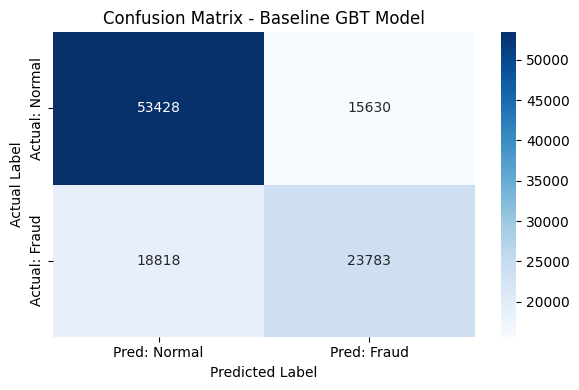

✅ Confusion matrix and 5 Indicators logged to MLflow successfully!
🔍 Extracting Feature Importance from the model...


2026/07/20 23:25:20 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/20 23:25:20 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


📊 Feature importances saved to: workspace.insurance_claim.gbt_feature_importances_baseline


In [0]:
## Base Model of GBT

# Model Training & MLflow Logging (Integrated with Pipeline & Feature Importance)

with mlflow.start_run(run_name="Baseline_GBTClassifier_Default") as run:
    
    # Save & Log Pipeline Model
    pipeline_path = "/Volumes/workspace/insurance_claim/mlflow_tmp/fraud_pipeline_model"
    pipeline_model.write().overwrite().save(pipeline_path)
    mlflow.spark.log_model(pipeline_model, "fraud_pipeline_model", dfs_tmpdir=tmp_vol_path)
    print(f"✅ Pipeline logged to MLflow and saved to: {pipeline_path}")

    ####### Model Building #######

    print("Training Baseline Model (GBT with default parameters)...")
    
    # Initialize GBTClassifier with default PySpark parameters
    # Note: maxBins is set to 10500 instead of default 32 to prevent the high-cardinality crash
    # Removed weightCol to test the model without class balancing
    gbt = GBTClassifier(
        featuresCol="features", 
        labelCol="is_fraud", 
        maxIter=20,                  # PySpark Default: 20
        maxDepth=5,                  # PySpark Default: 5
        stepSize=0.1,                # PySpark Default: 0.1
        maxBins=10500,               # Adjusted from default 32 to 10500 to handle Feature 35
        minInstancesPerNode=1,       # PySpark Default: 1
        featureSubsetStrategy="all"  # PySpark Default: "all"
    )
    
    # Train model using the original dataset (without weights)
    gbt_model = gbt.fit(train_data)
    
    # Evaluate
    evaluator = BinaryClassificationEvaluator(labelCol="is_fraud", metricName="areaUnderROC")
    gbt_predictions = gbt_model.transform(test_data)
    
    gbt_auc = evaluator.evaluate(gbt_predictions)
    
    # Log parameters and metrics for the Baseline Model
    mlflow.log_param("model_type", "Gradient Boosted Trees (Baseline)")
    mlflow.log_param("maxIter", 20)
    mlflow.log_param("stepSize", 0.1)
    mlflow.log_param("maxDepth", 5)
    mlflow.log_param("maxBins", 10500)
    mlflow.log_param("minInstancesPerNode", 1)
    mlflow.log_param("featureSubsetStrategy", "all")
    mlflow.log_param("use_class_weights", False) # Explicitly log that weights are NOT used
    mlflow.log_metric("ROC_AUC", gbt_auc)
    
    # Create Model Signature
    signature = infer_signature(
        model_input=train_data.select("features"), 
        model_output=gbt_predictions.select("prediction")
    )
    
    # Log model WITH signature attached
    mlflow.spark.log_model(
        spark_model=gbt_model, 
        artifact_path="baseline_model", 
        signature=signature,
        dfs_tmpdir=tmp_vol_path
    )
    print(f"✅ Baseline ROC AUC: {gbt_auc:.4f}")

    ############################
    
    # ==========================================
    # Evaluate Model & Calculate 5 Indicators
    # ==========================================
    print("📊 Generating Confusion Matrix, 5 Indicators, and Classification Report...")

    # Convert PySpark predictions on test_data to Pandas for Sklearn
    preds_pd = gbt_predictions.select("is_fraud", "prediction").toPandas()

    # Calculate Confusion Matrix and extract TP, TN, FP, FN values
    cm = confusion_matrix(preds_pd["is_fraud"], preds_pd["prediction"])
    tn, fp, fn, tp = cm.ravel()  # Extracted from 2x2 Matrix to 4 variables

    # Calculate 5 Indicators
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    # Display 5 indicators (Translated to English)
    print("\n📈 5 Key Performance Indicators:")
    print(f"1. Accuracy    (Overall correctness)               : {accuracy:.4f}")
    print(f"2. Precision   (True Frauds out of Predicted)      : {precision:.4f}")
    print(f"3. Recall      (Captured Frauds out of Actual)     : {recall:.4f}")
    print(f"4. F1-Score    (Harmonic mean of Prec & Recall)    : {f1_score:.4f}")
    print(f"5. Specificity (True Normals out of Actual)        : {specificity:.4f}")
    print("-" * 50)

    # Log Indicators into MLflow
    mlflow.log_metric("Accuracy", accuracy)
    mlflow.log_metric("Precision", precision)
    mlflow.log_metric("Recall", recall)
    mlflow.log_metric("F1_Score", f1_score)
    mlflow.log_metric("Specificity", specificity)
    
    # Log raw confusion matrix data
    mlflow.log_metric("True_Positives", tp)
    mlflow.log_metric("True_Negatives", tn)
    mlflow.log_metric("False_Positives", fp)
    mlflow.log_metric("False_Negatives", fn)

    # Print Classification Report
    print("\n📋 Classification Report:")
    print(
        classification_report(
            preds_pd["is_fraud"],
            preds_pd["prediction"],
            target_names=["Normal (0)", "Fraud (1)"],
        )
    )

    # Plot Confusion Matrix Heatmap
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred: Normal", "Pred: Fraud"],
        yticklabels=["Actual: Normal", "Actual: Fraud"],
        ax=ax,
    )
    plt.title("Confusion Matrix - Baseline GBT Model")
    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()

    # Save plot image and log to MLflow as an Artifact
    cm_plot_path = "/tmp/confusion_matrix.png"
    plt.savefig(cm_plot_path)
    mlflow.log_artifact(cm_plot_path, artifact_path="plots")
    plt.show()

    print("✅ Confusion matrix and 5 Indicators logged to MLflow successfully!")

    # Extract & Save Feature Importances
    print("🔍 Extracting Feature Importance from the model...")
    importances = gbt_model.featureImportances.toArray()
    
    importance_df = pd.DataFrame({
        'Feature': assembler_inputs,  # Extract variables from VectorAssembler
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    spark_importance_df = spark.createDataFrame(importance_df)
    
    # Changed table name to avoid overwriting the tuned model's importances
    importance_table_path = "workspace.insurance_claim.gbt_feature_importances_baseline"
    spark_importance_df.write.mode("overwrite").saveAsTable(importance_table_path)
    print(f"📊 Feature importances saved to: {importance_table_path}")

    # Automatically extract run_id for Model Registry
    run_id = run.info.run_id

2026/07/20 22:01:06 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/07/20 22:01:23 WARNING mlflow.utils.requirements_utils: Found pyspark version (4.1.0+databricks.connect.18.0.9) contains a local version label (+databricks.connect.18.0.9). MLflow logged a pip requirement for this package as 'pyspark==4.1.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/20 22:01:33 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /local_disk0/user_tmp_data/spark-dee91acb-eec3-41df-9067-4c/tmpgmoj4s08/model, flavor: spark). Fall back to return ['pyspark==4.1.0']. Set logging level to DEBUG to see the full traceback. 
2026/07/20 22:01:33 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate

✅ Pipeline logged to MLflow and saved to: /Volumes/workspace/insurance_claim/mlflow_tmp/fraud_pipeline_model
Training Challenger Model (GBT)...


2026/07/20 22:05:29 WARNING mlflow.utils.requirements_utils: Found pyspark version (4.1.0+databricks.connect.18.0.9) contains a local version label (+databricks.connect.18.0.9). MLflow logged a pip requirement for this package as 'pyspark==4.1.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/20 22:05:31 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /local_disk0/user_tmp_data/spark-dee91acb-eec3-41df-9067-4c/tmplihgw6c4/model, flavor: spark). Fall back to return ['pyspark==4.1.0']. Set logging level to DEBUG to see the full traceback. 


✅ Challenger ROC AUC: 0.7264
📊 Generating Confusion Matrix and Classification Report...

📋 Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.74      0.77      0.76     69058
   Fraud (1)       0.60      0.56      0.58     42601

    accuracy                           0.69    111659
   macro avg       0.67      0.67      0.67    111659
weighted avg       0.69      0.69      0.69    111659



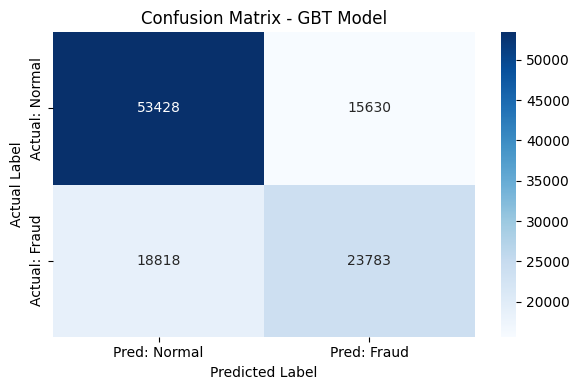

✅ Confusion matrix logged to MLflow successfully!
🔍 Extracting Feature Importance from the model...


2026/07/20 22:05:43 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/20 22:05:43 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


📊 Feature importances saved to: workspace.insurance_claim.gbt_feature_importances


In [0]:
# Model Training & MLflow Logging (Integrated with Pipeline & Feature Importance)
# fine-tuned 1 times


with mlflow.start_run(run_name="Challenger_GBTClassifier_With_Signature") as run:
    
    # Save & Log Pipeline Model
    pipeline_path = "/Volumes/workspace/insurance_claim/mlflow_tmp/fraud_pipeline_model"
    pipeline_model.write().overwrite().save(pipeline_path)
    mlflow.spark.log_model(pipeline_model, "fraud_pipeline_model", dfs_tmpdir=tmp_vol_path)
    print(f"✅ Pipeline logged to MLflow and saved to: {pipeline_path}")


    ####### Model Building #######

    print("Training Challenger Model (GBT)...")
    
    # Train Model
    gbt = GBTClassifier(
        featuresCol="features", 
        labelCol="is_fraud", 
        maxIter=20,     
        maxDepth=5,     
        maxBins=15000
    )
    gbt_model = gbt.fit(train_data)
    
    # Evaluate
    evaluator = BinaryClassificationEvaluator(labelCol="is_fraud", metricName="areaUnderROC")
    gbt_predictions = gbt_model.transform(test_data)
    gbt_auc = evaluator.evaluate(gbt_predictions)
    
    # Log parameters and metrics
    mlflow.log_param("model_type", "Gradient Boosted Trees")
    mlflow.log_param("maxIter", 20)
    mlflow.log_param("maxDepth", 5)
    mlflow.log_param("maxBins", 15000)
    mlflow.log_metric("ROC_AUC", gbt_auc)
    
    # Create Model Signature
    signature = infer_signature(
        model_input=train_data.select("features"), 
        model_output=gbt_predictions.select("prediction")
    )
    
    # Log model WITH signature attached
    mlflow.spark.log_model(
        spark_model=gbt_model, 
        artifact_path="challenger_model", 
        signature=signature,
        dfs_tmpdir=tmp_vol_path
    )
    print(f"✅ Challenger ROC AUC: {gbt_auc:.4f}")

    ############################

    # ==========================================
    # Evaluate Model & Calculate 5 Indicators
    # ==========================================
    print("📊 Generating Confusion Matrix, 5 Indicators, and Classification Report...")

    # Convert PySpark predictions on test_data to Pandas for Sklearn
    preds_pd = gbt_predictions.select("is_fraud", "prediction").toPandas()

    # Calculate Confusion Matrix and extract TP, TN, FP, FN values
    cm = confusion_matrix(preds_pd["is_fraud"], preds_pd["prediction"])
    tn, fp, fn, tp = cm.ravel()  # from 2x2 Matrix to 4 variables

    # Calculate 5 Indicators
    
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    # Display 5 indicators
    print("\n📈 5 Key Performance Indicators:")
    print(f"1. Accuracy    (ความถูกต้องรวม)                  : {accuracy:.4f}")
    print(f"2. Precision   (ทายว่า Fraud แล้วเป็น Fraud จริง)   : {precision:.4f}")
    print(f"3. Recall      (จับ Fraud จากทั้งหมดได้แค่ไหน)      : {recall:.4f}")
    print(f"4. F1-Score    (ค่าเฉลี่ยสมดุล Precision & Recall) : {f1_score:.4f}")
    print(f"5. Specificity (จับรายการปกติได้ถูกต้องแค่ไหน)       : {specificity:.4f}")
    print("-" * 50)

    # Log Indicators into MLflow
    mlflow.log_metric("Accuracy", accuracy)
    mlflow.log_metric("Precision", precision)
    mlflow.log_metric("Recall", recall)
    mlflow.log_metric("F1_Score", f1_score)
    mlflow.log_metric("Specificity", specificity)
    # Log raw data
    mlflow.log_metric("True_Positives", tp)
    mlflow.log_metric("True_Negatives", tn)
    mlflow.log_metric("False_Positives", fp)
    mlflow.log_metric("False_Negatives", fn)

    # Print Classification Report (traditional)
    print("\n📋 Classification Report:")
    print(
        classification_report(
            preds_pd["is_fraud"],
            preds_pd["prediction"],
            target_names=["Normal (0)", "Fraud (1)"],
        )
    )

    # Plot Confusion Matrix Heatmap
    cm = confusion_matrix(preds_pd["is_fraud"], preds_pd["prediction"])

    # Plot Confusion Matrix Heatmap
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred: Normal", "Pred: Fraud"],
        yticklabels=["Actual: Normal", "Actual: Fraud"],
        ax=ax,
    )
    plt.title("Confusion Matrix - GBT Model")
    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()

    # Save plot image and log to MLflow as an Artifact
    cm_plot_path = "/tmp/confusion_matrix.png"
    plt.savefig(cm_plot_path)
    mlflow.log_artifact(cm_plot_path, artifact_path="plots")
    plt.show()

    print("✅ Confusion matrix and 5 Indicators logged to MLflow successfully!")

    # Extract & Save Feature Importances

    print("🔍 Extracting Feature Importance from the model...")
    importances = gbt_model.featureImportances.toArray()
    
    importance_df = pd.DataFrame({
        'Feature': assembler_inputs,  # extract variables from VectorAssembler
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    spark_importance_df = spark.createDataFrame(importance_df)
    importance_table_path = "workspace.insurance_claim.gbt_feature_importances"
    spark_importance_df.write.mode("overwrite").saveAsTable(importance_table_path)
    print(f"📊 Feature importances saved to: {importance_table_path}")

    # Automately extract run_id for Model Registry
    run_id = run.info.run_id

### Fine-Tuned GBT model

2026/07/20 22:32:16 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/07/20 22:32:30 WARNING mlflow.utils.requirements_utils: Found pyspark version (4.1.0+databricks.connect.18.0.9) contains a local version label (+databricks.connect.18.0.9). MLflow logged a pip requirement for this package as 'pyspark==4.1.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/20 22:32:32 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /local_disk0/user_tmp_data/spark-dee91acb-eec3-41df-9067-4c/tmpqy8o1dm6/model, flavor: spark). Fall back to return ['pyspark==4.1.0']. Set logging level to DEBUG to see the full traceback. 
2026/07/20 22:32:32 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate

✅ Pipeline logged to MLflow and saved to: /Volumes/workspace/insurance_claim/mlflow_tmp/fraud_pipeline_model
Training Challenger Model (GBT)...


The random forest training stops early because the model size (969056 bytes) exceeds threshold (421950 bytes).
The boosting tree training stops early because the GBT accumulated tree models size (107921264 bytes) exceeds threshold (107374182 bytes).
2026/07/20 22:44:38 WARNING mlflow.utils.requirements_utils: Found pyspark version (4.1.0+databricks.connect.18.0.9) contains a local version label (+databricks.connect.18.0.9). MLflow logged a pip requirement for this package as 'pyspark==4.1.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/20 22:44:40 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /local_disk0/user_tmp_data/spark-dee91acb-eec3-41df-9067-4c/tmp00o8g2_4/model, flavor: spark). Fall back to return ['pyspark==4.1.0']. Set logging level to DEBUG to see the full traceback. 


✅ Challenger ROC AUC: 0.7386
📊 Generating Confusion Matrix, 5 Indicators, and Classification Report...

📈 5 Key Performance Indicators:
1. Accuracy    (ความถูกต้องรวม)                  : 0.6874
2. Precision   (ทายว่า Fraud แล้วเป็น Fraud จริง)   : 0.5750
3. Recall      (จับ Fraud จากทั้งหมดได้แค่ไหน)      : 0.6918
4. F1-Score    (ค่าเฉลี่ยสมดุล Precision & Recall) : 0.6280
5. Specificity (จับรายการปกติได้ถูกต้องแค่ไหน)       : 0.6846
--------------------------------------------------

📋 Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.78      0.68      0.73     69058
   Fraud (1)       0.58      0.69      0.63     42601

    accuracy                           0.69    111659
   macro avg       0.68      0.69      0.68    111659
weighted avg       0.70      0.69      0.69    111659



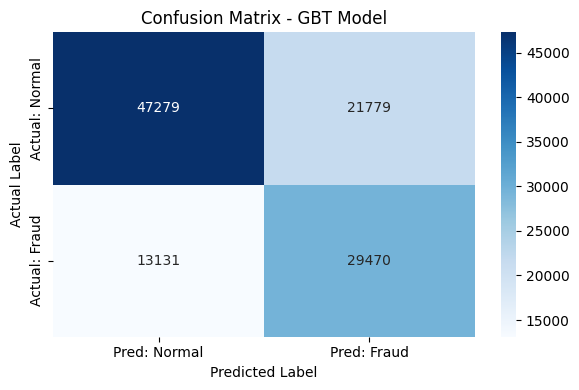

✅ Confusion matrix and 5 Indicators logged to MLflow successfully!
🔍 Extracting Feature Importance from the model...


2026/07/20 22:44:54 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/20 22:44:54 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


📊 Feature importances saved to: workspace.insurance_claim.gbt_feature_importances


In [0]:
# Model Training & MLflow Logging (Integrated with Pipeline & Feature Importance)

with mlflow.start_run(run_name="Challenger_GBTClassifier_Tuned") as run:
    
    # Save & Log Pipeline Model
    pipeline_path = "/Volumes/workspace/insurance_claim/mlflow_tmp/fraud_pipeline_model"
    pipeline_model.write().overwrite().save(pipeline_path)
    mlflow.spark.log_model(pipeline_model, "fraud_pipeline_model", dfs_tmpdir=tmp_vol_path)
    print(f"✅ Pipeline logged to MLflow and saved to: {pipeline_path}")

    ####### Model Building #######

    print("Training Challenger Model (GBT)...")
    
    # [เพิ่มเติม] 1. คำนวณ Class Weights เพื่อแก้ปัญหา Imbalance
    # สมมติว่าใน train_data มีคอลัมน์ 'is_fraud' 
    # ให้ค่าน้ำหนักกับคลาส Fraud (1) มากกว่าคลาส Normal (0)
    fraud_count = train_data.filter(train_data.is_fraud == 1).count()
    normal_count = train_data.filter(train_data.is_fraud == 0).count()
    total_count = fraud_count + normal_count
    
    # น้ำหนัก = (จำนวนทั้งหมด) / (จำนวนคลาสนั้น * จำนวนคลาสทั้งหมด)
    weight_fraud = total_count / (2 * fraud_count)
    weight_normal = total_count / (2 * normal_count)
    
    from pyspark.sql.functions import when, lit
    train_data_weighted = train_data.withColumn(
        "class_weight", 
        when(train_data.is_fraud == 1, lit(weight_fraud)).otherwise(lit(weight_normal))
    )

    # 2. ปรับจูน Parameters ให้ GBT 
    gbt = GBTClassifier(
        featuresCol="features", 
        labelCol="is_fraud", 
        weightCol="class_weight",     # [ใหม่] บังคับให้โมเดลสนใจคลาส Fraud มากขึ้น
        maxIter=100,                  # [ปรับ] เพิ่มจำนวนต้นไม้จาก 20 เป็น 100
        stepSize=0.1,                 # [ใหม่] ควบคุม Learning Rate ป้องกันโมเดลเรียนรู้เร็วไป
        maxDepth=5,                   # [คงเดิม] 5 ถือว่ากำลังดี ไม่ลึกเกินไปจน Overfit
        maxBins=10500,                  # [ปรับ] ลดจาก 15000 ลงมาเหลือ 128 เพื่อให้เทรนเร็วขึ้นมาก
        minInstancesPerNode=5,        # [ใหม่] ป้องกัน Overfitting โดยบังคับให้ใบต้องมีข้อมูลอย่างน้อย 5 record
        featureSubsetStrategy="auto"  # [ใหม่] สุ่มฟีเจอร์มาสร้างต้นไม้ (เหมือน Random Forest) ลดความจำเจ
    )
    
    # เทรนโมเดลด้วยข้อมูลที่มีคอลัมน์ class_weight
    gbt_model = gbt.fit(train_data_weighted)
    
    # Evaluate
    evaluator = BinaryClassificationEvaluator(labelCol="is_fraud", metricName="areaUnderROC")
    gbt_predictions = gbt_model.transform(test_data)
    
    # [ทบทวนจากบทสนทนาก่อนหน้า] หากต้องการปรับ Threshold ให้ใช้ probability column
    # ตัวอย่าง: ปรับ Threshold เป็น 0.3 เพื่อเพิ่ม Recall 
    # from pyspark.ml.functions import vector_to_array
    # gbt_predictions = gbt_predictions.withColumn("fraud_prob", vector_to_array(F.col("probability"))[1])
    # gbt_predictions = gbt_predictions.withColumn("prediction", F.when(F.col("fraud_prob") >= 0.3, 1.0).otherwise(0.0))

    gbt_auc = evaluator.evaluate(gbt_predictions)
    
    # Log parameters and metrics (อัปเดตตามที่เพิ่มเข้าไป)
    mlflow.log_param("model_type", "Gradient Boosted Trees")
    mlflow.log_param("maxIter", 100)
    mlflow.log_param("stepSize", 0.1)
    mlflow.log_param("maxDepth", 5)
    mlflow.log_param("maxBins", 10500)
    mlflow.log_param("minInstancesPerNode", 5)
    mlflow.log_param("use_class_weights", True)
    mlflow.log_metric("ROC_AUC", gbt_auc)
    
    # Create Model Signature
    signature = infer_signature(
        model_input=train_data.select("features"), 
        model_output=gbt_predictions.select("prediction")
    )
    
    # Log model WITH signature attached
    mlflow.spark.log_model(
        spark_model=gbt_model, 
        artifact_path="challenger_model", 
        signature=signature,
        dfs_tmpdir=tmp_vol_path
    )
    print(f"✅ Challenger ROC AUC: {gbt_auc:.4f}")

    ############################
    
    # ==========================================
    # Evaluate Model & Calculate 5 Indicators
    # ==========================================
    print("📊 Generating Confusion Matrix, 5 Indicators, and Classification Report...")

    # Convert PySpark predictions on test_data to Pandas for Sklearn
    preds_pd = gbt_predictions.select("is_fraud", "prediction").toPandas()

    # Calculate Confusion Matrix and extract TP, TN, FP, FN values
    cm = confusion_matrix(preds_pd["is_fraud"], preds_pd["prediction"])
    tn, fp, fn, tp = cm.ravel()  # from 2x2 Matrix to 4 variables

    # Calculate 5 Indicators
    
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    # Display 5 indicators
    print("\n📈 5 Key Performance Indicators:")
    print(f"1. Accuracy    (ความถูกต้องรวม)                  : {accuracy:.4f}")
    print(f"2. Precision   (ทายว่า Fraud แล้วเป็น Fraud จริง)   : {precision:.4f}")
    print(f"3. Recall      (จับ Fraud จากทั้งหมดได้แค่ไหน)      : {recall:.4f}")
    print(f"4. F1-Score    (ค่าเฉลี่ยสมดุล Precision & Recall) : {f1_score:.4f}")
    print(f"5. Specificity (จับรายการปกติได้ถูกต้องแค่ไหน)       : {specificity:.4f}")
    print("-" * 50)

    # Log Indicators into MLflow
    mlflow.log_metric("Accuracy", accuracy)
    mlflow.log_metric("Precision", precision)
    mlflow.log_metric("Recall", recall)
    mlflow.log_metric("F1_Score", f1_score)
    mlflow.log_metric("Specificity", specificity)
    # Log raw data
    mlflow.log_metric("True_Positives", tp)
    mlflow.log_metric("True_Negatives", tn)
    mlflow.log_metric("False_Positives", fp)
    mlflow.log_metric("False_Negatives", fn)

    # Print Classification Report (traditional)
    print("\n📋 Classification Report:")
    print(
        classification_report(
            preds_pd["is_fraud"],
            preds_pd["prediction"],
            target_names=["Normal (0)", "Fraud (1)"],
        )
    )

    # Plot Confusion Matrix Heatmap
    cm = confusion_matrix(preds_pd["is_fraud"], preds_pd["prediction"])

    # Plot Confusion Matrix Heatmap
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred: Normal", "Pred: Fraud"],
        yticklabels=["Actual: Normal", "Actual: Fraud"],
        ax=ax,
    )
    plt.title("Confusion Matrix - GBT Model")
    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()

    # Save plot image and log to MLflow as an Artifact
    cm_plot_path = "/tmp/confusion_matrix.png"
    plt.savefig(cm_plot_path)
    mlflow.log_artifact(cm_plot_path, artifact_path="plots")
    plt.show()

    print("✅ Confusion matrix and 5 Indicators logged to MLflow successfully!")

    # Extract & Save Feature Importances

    print("🔍 Extracting Feature Importance from the model...")
    importances = gbt_model.featureImportances.toArray()
    
    importance_df = pd.DataFrame({
        'Feature': assembler_inputs,  # extract variables from VectorAssembler
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    spark_importance_df = spark.createDataFrame(importance_df)
    importance_table_path = "workspace.insurance_claim.gbt_feature_importances"
    spark_importance_df.write.mode("overwrite").saveAsTable(importance_table_path)
    print(f"📊 Feature importances saved to: {importance_table_path}")

    # Automately extract run_id for Model Registry
    run_id = run.info.run_id

## Register the Winning Model to Unity Catalog

In [0]:
# Register the Winning Model to Unity Catalog

print("\n--- Registering Model to Unity Catalog ---")

model_name = "workspace.insurance_claim.fraud_gbt_model"
model_uri = f"runs:/{run_id}/challenger_model"

try:
    registered_model = mlflow.register_model(
        model_uri=model_uri,
        name=model_name
    )
    print(f"✅ Successfully registered model: {registered_model.name} (Version: {registered_model.version})")

except Exception as e:
    print(f"❌ Error registering model: {e}")


--- Registering Model to Unity Catalog ---


Registered model 'workspace.insurance_claim.fraud_gbt_model' already exists. Creating a new version of this model...


❌ Error registering model: Unable to find a logged_model with artifact_path challenger_model under run b20e48ed8da54ac08a0db07fe2b82676


### Business Cost Assumptions

In [0]:
# Define business cost assumptions (Adjust these numbers to reflect reality)

COST_PER_FRAUD = 10000      # Average loss per undetected fraud case (FN) - THB
COST_PER_FP = 300           # Cost of investigating a false alarm (FP) - THB
COMPUTE_COST_PER_MIN = 50   # Cloud/Server computing cost per minute - THB


In [0]:
# Performance metrics of both models

models = {
    "Model 1 (Baseline)": {
        "TP": 23783,
        "FN": 18818,
        "FP": 15630,
        "TN": 53428,
        "Time_Mins": 5
    },
    "Model 2 (Fine-Tuned)": {
        "TP": 29470,
        "FN": 13131,
        "FP": 21779,
        "TN": 47279,
        "Time_Mins": 13
    }
}

In [0]:
# Calculate costs for each component

results = []
for model_name, metrics in models.items():
    # Calculate costs
    fraud_loss = metrics["FN"] * COST_PER_FRAUD
    fp_cost = metrics["FP"] * COST_PER_FP
    compute_cost = metrics["Time_Mins"] * COMPUTE_COST_PER_MIN
    
    total_cost = fraud_loss + fp_cost + compute_cost
    
    results.append({
        "Model": model_name,
        "Fraud Loss (FN)": fraud_loss,
        "Operation Cost (FP)": fp_cost,
        "Compute Cost (Time)": compute_cost,
        "Total Cost": total_cost
    })

df_results = pd.DataFrame(results)

In [0]:
# Compare and display results

baseline_cost = df_results.loc[df_results["Model"] == "Model 1 (Baseline)", "Total Cost"].values[0]
new_model_cost = df_results.loc[df_results["Model"] == "Model 2 (Fine-Tuned)", "Total Cost"].values[0]

net_saving = baseline_cost - new_model_cost

# Format numbers for readability (add commas)
pd.options.display.float_format = '{:,.0f}'.format
print("📊 Business Cost Analysis Summary")
print("-" * 100)
print(df_results.to_string(index=False))
print("-" * 100)

if net_saving > 0:
    print(f"✅ Model 2 (Fine-Tuned) is more cost-effective!")
    print(f"💰 Net savings for the business: {net_saving:,.2f} THB")
else:
    print(f"❌ Model 2 (Fine-Tuned) has a higher total cost.")
    print(f"💸 Additional loss for the business: {abs(net_saving):,.2f} THB")

📊 Business Cost Analysis Summary
----------------------------------------------------------------------------------------------------
               Model  Fraud Loss (FN)  Operation Cost (FP)  Compute Cost (Time)  Total Cost
  Model 1 (Baseline)        188180000              4689000                  250   192869250
Model 2 (Fine-Tuned)        131310000              6533700                  650   137844350
----------------------------------------------------------------------------------------------------
✅ Model 2 (Fine-Tuned) is more cost-effective!
💰 Net savings for the business: 55,024,900.00 THB


### Baseline Model (Logistic Regression)

In [0]:
# =============================================================================
# 🟢 RUN 1: Baseline Model (Logistic Regression)
# =============================================================================

with mlflow.start_run(run_name="Baseline_LogisticRegression"):
    print("Training Baseline Model...")
    lr = LogisticRegression(featuresCol="features", labelCol="is_fraud", maxIter=10)
    lr_model = lr.fit(train_data)
    
    # Make predictions and evaluate
    lr_predictions = lr_model.transform(test_data)
    lr_auc = evaluator.evaluate(lr_predictions)
    
    # Log parameters and metrics
    mlflow.log_param("model_type", "Logistic Regression")
    mlflow.log_metric("ROC_AUC", lr_auc)
    
    # add variable: dfs_tmpdir to point at UC Volume
    mlflow.spark.log_model(lr_model, "baseline_model", dfs_tmpdir=tmp_vol_path)
    
    print(f"✅ Baseline ROC AUC: {lr_auc:.4f}")

2026/07/20 01:54:00 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o26.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:27)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:17)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumented

Training Baseline Model...


2026/07/20 01:54:21 WARNING mlflow.utils.requirements_utils: Found pyspark version (4.1.0+databricks.connect.18.0.9) contains a local version label (+databricks.connect.18.0.9). MLflow logged a pip requirement for this package as 'pyspark==4.1.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/20 01:54:24 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /local_disk0/user_tmp_data/spark-3619d855-fced-4777-b97f-58/tmpibkep6uu/model, flavor: spark). Fall back to return ['pyspark==4.1.0']. Set logging level to DEBUG to see the full traceback. 
2026/07/20 01:54:24 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when l

✅ Baseline ROC AUC: 0.6228


### Challenger Model (Random Forest)

In [0]:
# =============================================================================
# 🔵 RUN 2/1: Challenger Model (Random Forest)
# =============================================================================

with mlflow.start_run(run_name="Challenger_RandomForest"):
    print("Training Challenger Model...")
    rf = RandomForestClassifier(
    featuresCol="features", 
    labelCol="is_fraud", 
    numTrees=50, 
    maxDepth=5,
    maxBins=15000
    )
    rf_model = rf.fit(train_data)
    
    # Make predictions and evaluate
    rf_predictions = rf_model.transform(test_data)
    rf_auc = evaluator.evaluate(rf_predictions)
    
    # Log parameters and metrics
    mlflow.log_param("model_type", "Random Forest")
    mlflow.log_param("numTrees", 50)
    mlflow.log_param("maxDepth", 5)
    mlflow.log_metric("ROC_AUC", rf_auc)
    
    # add variable: dfs_tmpdir to pint at UC Volume
    mlflow.spark.log_model(rf_model, "challenger_model", dfs_tmpdir=tmp_vol_path)
    
    print(f"✅ Challenger ROC AUC: {rf_auc:.4f}")

2026/07/20 02:05:08 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o62.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:27)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:17)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumented

Training Challenger Model...


2026/07/20 02:07:48 WARNING mlflow.utils.requirements_utils: Found pyspark version (4.1.0+databricks.connect.18.0.9) contains a local version label (+databricks.connect.18.0.9). MLflow logged a pip requirement for this package as 'pyspark==4.1.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/20 02:07:50 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /local_disk0/user_tmp_data/spark-3619d855-fced-4777-b97f-58/tmpo17jrl71/model, flavor: spark). Fall back to return ['pyspark==4.1.0']. Set logging level to DEBUG to see the full traceback. 
2026/07/20 02:07:50 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when l

✅ Challenger ROC AUC: 0.6880


In [0]:
# =============================================================================
# 🔵 RUN 2/2: Challenger Model (Random Forest)
# =============================================================================

with mlflow.start_run(run_name="Challenger_RandomForest"):
    print("Training Challenger Model...")
    
    # ADDED: maxBins=15000 to handle high cardinality in categorical features
    rf = RandomForestClassifier(
        featuresCol="features", 
        labelCol="is_fraud", 
        numTrees=50, 
        maxDepth=5,
        maxBins=15000 
    )
    rf_model = rf.fit(train_data)
    
    # Make predictions on the test set and evaluate the model
    rf_predictions = rf_model.transform(test_data)
    rf_auc = evaluator.evaluate(rf_predictions)
    
    # Log model parameters to MLflow for tracking and comparison
    mlflow.log_param("model_type", "Random Forest")
    mlflow.log_param("numTrees", 50)
    mlflow.log_param("maxDepth", 5)
    mlflow.log_param("maxBins", 15000) # ADDED: Good practice to log the modified maxBins
    
    # Log the evaluation metric (ROC AUC)
    mlflow.log_metric("ROC_AUC", rf_auc)
    
    # ADDED: dfs_tmpdir=tmp_vol_path to safely log the model via Unity Catalog Volume 
    # (Bypasses restrictions on Databricks Shared/Serverless clusters)
    mlflow.spark.log_model(rf_model, "challenger_model", dfs_tmpdir=tmp_vol_path)
    
    print(f"✅ Challenger ROC AUC: {rf_auc:.4f}")

2026/07/20 02:22:12 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o80.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:27)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:17)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumented

Training Challenger Model...


2026/07/20 02:24:56 WARNING mlflow.utils.requirements_utils: Found pyspark version (4.1.0+databricks.connect.18.0.9) contains a local version label (+databricks.connect.18.0.9). MLflow logged a pip requirement for this package as 'pyspark==4.1.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/20 02:24:58 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /local_disk0/user_tmp_data/spark-3619d855-fced-4777-b97f-58/tmpxtqt_4a6/model, flavor: spark). Fall back to return ['pyspark==4.1.0']. Set logging level to DEBUG to see the full traceback. 
2026/07/20 02:24:58 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when l

✅ Challenger ROC AUC: 0.6880


### Updated Strategy
Goal: Use Default Random Forest as Baseline, and GBT as Challenger

In [0]:
# =============================================================================
# 🟢 RUN 3: NEW Baseline Model (Default Random Forest)
# =============================================================================
with mlflow.start_run(run_name="Baseline_Default_RandomForest"):
    print("Training Baseline Model (Default RF)...")
    
    # Using mostly default parameters (except maxBins for your specific data)
    rf_default = RandomForestClassifier(
        featuresCol="features", 
        labelCol="is_fraud",
        maxBins=15000 
        # Not setting numTrees or maxDepth here, letting Spark use its defaults
    )
    rf_baseline_model = rf_default.fit(train_data)
    
    # Evaluate
    baseline_predictions = rf_baseline_model.transform(test_data)
    baseline_auc = evaluator.evaluate(baseline_predictions)
    
    # Log parameters and metrics
    mlflow.log_param("model_type", "Random Forest (Default)")
    mlflow.log_param("maxBins", 15000)
    mlflow.log_metric("ROC_AUC", baseline_auc)
    
    # Log model to UC Volume
    mlflow.spark.log_model(rf_baseline_model, "baseline_model", dfs_tmpdir=tmp_vol_path)
    print(f"✅ Baseline ROC AUC: {baseline_auc:.4f}")

2026/07/20 02:27:51 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o109.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:27)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:17)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumente

Training Baseline Model (Default RF)...


2026/07/20 02:29:01 WARNING mlflow.utils.requirements_utils: Found pyspark version (4.1.0+databricks.connect.18.0.9) contains a local version label (+databricks.connect.18.0.9). MLflow logged a pip requirement for this package as 'pyspark==4.1.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/20 02:29:03 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /local_disk0/user_tmp_data/spark-3619d855-fced-4777-b97f-58/tmpssvx_sz6/model, flavor: spark). Fall back to return ['pyspark==4.1.0']. Set logging level to DEBUG to see the full traceback. 
2026/07/20 02:29:03 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when l

✅ Baseline ROC AUC: 0.6815


In [0]:
# =============================================================================
# 🔵 RUN 4/1: Gradient Boosted Trees
# =============================================================================

with mlflow.start_run(run_name="Challenger_GBTClassifier_With_Signature"):
    print("Training Challenger Model (GBT)...")
    
    # 1. Train Model
    gbt = GBTClassifier(
        featuresCol="features", 
        labelCol="is_fraud", 
        maxIter=20,     
        maxDepth=5,     
        maxBins=15000
    )
    gbt_model = gbt.fit(train_data)
    
    # 2. Evaluate
    gbt_predictions = gbt_model.transform(test_data)
    gbt_auc = evaluator.evaluate(gbt_predictions)
    
    # Log parameters and metrics
    mlflow.log_param("model_type", "Gradient Boosted Trees")
    mlflow.log_param("maxIter", 20)
    mlflow.log_param("maxDepth", 5)
    mlflow.log_param("maxBins", 15000)
    mlflow.log_metric("ROC_AUC", gbt_auc)
    
    # =============================================================================
    # 🌟 NEW: Create Model Signature
    # Tells Unity Catalog the exact schema of inputs and outputs
    # =============================================================================
    signature = infer_signature(
        model_input=train_data.select("features"), 
        model_output=gbt_predictions.select("prediction")
    )
    
    # =============================================================================
    # 🌟 MODIFIED: Log model WITH signature attached
    # =============================================================================
    mlflow.spark.log_model(
        spark_model=gbt_model, 
        artifact_path="challenger_model", 
        signature=signature,
        dfs_tmpdir=tmp_vol_path
    )
    print(f"✅ Challenger ROC AUC: {gbt_auc:.4f}")

2026/07/20 05:16:26 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o25.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:27)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:17)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumented

Training Challenger Model (GBT)...


2026/07/20 05:22:06 WARNING mlflow.utils.requirements_utils: Found pyspark version (4.1.0+databricks.connect.18.0.9) contains a local version label (+databricks.connect.18.0.9). MLflow logged a pip requirement for this package as 'pyspark==4.1.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/20 05:22:10 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /local_disk0/user_tmp_data/spark-66ff9894-7e5a-4a0e-a034-30/tmprunf4tlt/model, flavor: spark). Fall back to return ['pyspark==4.1.0']. Set logging level to DEBUG to see the full traceback. 


✅ Challenger ROC AUC: 0.7275


### Hyperparameter Tuning for GBT Classifier using CrossValidator

In [0]:
# =============================================================================
# 🚀 RUN 4/2: Hyperparameter Tuning for GBT
# =============================================================================

with mlflow.start_run(run_name="Tuned_GBTClassifier_TVS"):
    print("Starting Memory-Friendly Tuning for GBT...")
    
    # Initialize Base GBT 
    gbt = GBTClassifier(featuresCol="features", labelCol="is_fraud", maxBins=15000)
    
    # Create Parameter Grid (8 combinations)
    paramGrid = ParamGridBuilder() \
        .addGrid(gbt.maxIter, [20, 50]) \
        .addGrid(gbt.maxDepth, [4, 6]) \
        .addGrid(gbt.stepSize, [0.1, 0.05]) \
        .build()
    
    # 🌟 THE FIX: Use TrainValidationSplit instead of CrossValidator
    # This evaluates each parameter combination only ONCE (using 80% train / 20% validation)
    # It trains 8 models total instead of 24, bypassing the 1GB cache limit!
    tvs = TrainValidationSplit(
        estimator=gbt,
        estimatorParamMaps=paramGrid,
        evaluator=evaluator,
        trainRatio=0.8  # 80% of train_data used for training, 20% for validation during tuning
        # Removed parallelism to keep memory footprint minimal
    )
    
    # Train Models (This will be much faster and consume less memory)
    tvs_model = tvs.fit(train_data)
    best_gbt = tvs_model.bestModel
    
    # Evaluate the BEST Model on the Hold-out Test Set
    best_predictions = best_gbt.transform(test_data)
    best_auc = evaluator.evaluate(best_predictions)
    
    # Log parameters of the winning model to MLflow
    mlflow.log_param("model_type", "Tuned GBT (TVS)")
    mlflow.log_param("best_maxIter", best_gbt.getMaxIter())
    mlflow.log_param("best_maxDepth", best_gbt.getMaxDepth())
    mlflow.log_param("best_stepSize", best_gbt.getStepSize())
    mlflow.log_metric("ROC_AUC", best_auc)
    
    # Log the best model safely
    mlflow.spark.log_model(best_gbt, "tuned_gbt_model", dfs_tmpdir=tmp_vol_path)
    
    print(f"✅ Tuned GBT ROC AUC: {best_auc:.4f}")
    print(f"🏆 Winning Parameters: maxIter={best_gbt.getMaxIter()}, maxDepth={best_gbt.getMaxDepth()}, stepSize={best_gbt.getStepSize()}")

2026/07/20 04:05:24 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o11.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:27)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:17)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrumented

Starting Memory-Friendly Tuning for GBT...


The random forest training stops early because the model size (1537160 bytes) exceeds threshold (1342678 bytes).
The boosting tree training stops early because the GBT accumulated tree models size (107568640 bytes) exceeds threshold (107374182 bytes).
{"ts": "2026-07-20 05:13:05.238", "level": "ERROR", "logger": "pyspark.sql.connect.logging", "msg": "GRPC Error received", "context": {}, "exception": {"class": "_MultiThreadedRendezvous", "msg": "<_MultiThreadedRendezvous of RPC that terminated with:\n\tstatus = StatusCode.INTERNAL\n\tdetails = \"[OPERATION_CANCELED] Operation has been canceled. SQLSTATE: HY008\"\n\tdebug_error_string = \"UNKNOWN:Error received from peer ipv4:127.0.0.1:7073 {grpc_message:\"[OPERATION_CANCELED] Operation has been canceled. SQLSTATE: HY008\", grpc_status:13, created_time:\"2026-07-20T05:13:05.237795638+00:00\"}\"\n>", "stacktrace": [{"class": null, "method": "_execute_and_fetch_as_iterator", "file": "/databricks/python/lib/python3.12/site-packages/pyspark/